# EDA — Hyperspektrale Kulturpflanzen-Klassifikation
Explorative Datenanalyse von `train.csv` fuer Meilenstein 1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv')
spec_cols = [c for c in df.columns if c.startswith('X')]
print('Shape:', df.shape)
print('Anzahl Spektralband-Spalten:', len(spec_cols))
df.head()

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xf. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.

Shape: (5591, 204)
Anzahl Spektralband-Spalten: 198


,Unnamed: 0,AEZ,Month,Crop,Stage,X427,X437,X447,X457,X468,...,X2315,X2325,X2335,X2345,X2355,X2365,X2375,X2385,X2395,id
0,0,10,8,corn,Critical,NaN,21.380647,19.123425,17.686109,17.341397,...,4.614991,4.159126,3.969469,4.008810,NaN,NaN,NaN,NaN,NaN,train_0
1,1,10,8,corn,Critical,NaN,20.156616,18.015525,16.671422,16.203317,...,4.736217,4.596522,5.008663,5.293355,NaN,NaN,NaN,NaN,NaN,train_1
2,2,8,8,corn,Critical,NaN,15.149693,13.715446,13.172751,12.812346,...,5.219686,4.235294,4.448717,5.725971,NaN,NaN,NaN,NaN,NaN,train_2
3,3,10,8,corn,Critical,NaN,16.668828,14.892895,13.907130,13.593934,...,6.839068,6.024881,5.841306,5.888424,NaN,NaN,NaN,NaN,NaN,train_3
4,4,10,7,corn,Critical,NaN,17.949177,16.185521,15.237852,15.011519,...,5.754674,5.626414,4.952164,4.013303,NaN,NaN,NaN,NaN,NaN,train_4


## Fehlende Werte in den Spektralbaendern

In [2]:
na_frac = df[spec_cols].isna().mean()
full_na = na_frac[na_frac == 1.0]
partial_na = na_frac[(na_frac > 0) & (na_frac < 1.0)]
print(f'Komplett leere Spektralband-Spalten: {len(full_na)} von {len(spec_cols)}')
print(f'Teilweise fehlende Spalten: {len(partial_na)}')
print('Max. Fehlanteil bei teilweise fehlenden Spalten:', round(partial_na.max() * 100, 2), '%')
print('Zeilen ohne jegliche NaN:', (df[spec_cols].isna().sum(axis=1) == 0).sum(), '/', len(df))
list(full_na.index)

Komplett leere Spektralband-Spalten: 67 von 198
Teilweise fehlende Spalten: 6
Max. Fehlanteil bei teilweise fehlenden Spalten: 0.43 %
Zeilen ohne jegliche NaN: 0 / 5591


['X427',
 'X925',
 'X933',
 'X943',
 'X953',
 'X963',
 'X973',
 'X1104',
 'X1114',
 'X1124',
 'X1134',
 'X1144',
 'X1155',
 'X1165',
 'X1326',
 'X1336',
 'X1346',
 'X1356',
 'X1366',
 'X1377',
 'X1387',
 'X1397',
 'X1407',
 'X1417',
 'X1427',
 'X1437',
 'X1447',
 'X1457',
 'X1467',
 'X1477',
 'X1488',
 'X1498',
 'X1508',
 'X1770',
 'X1780',
 'X1790',
 'X1800',
 'X1810',
 'X1820',
 'X1831',
 'X1841',
 'X1851',
 'X1861',
 'X1871',
 'X1881',
 'X1891',
 'X1901',
 'X1911',
 'X1921',
 'X1931',
 'X1942',
 'X1952',
 'X1962',
 'X1972',
 'X1982',
 'X1992',
 'X2002',
 'X2012',
 'X2022',
 'X2032',
 'X2042',
 'X2052',
 'X2355',
 'X2365',
 'X2375',
 'X2385',
 'X2395']

**Beobachtung:** Die komplett leeren Baender liegen in den Bereichen ~925-973nm, ~1104-1165nm, ~1326-1508nm, ~1770-2052nm und ~2355-2395nm. Das entspricht bekannten Wasserdampf-Absorptionsbereichen bzw. verrauschten SWIR-Randbereichen des Hyperion-Sensors und ist damit fachlich plausibel unbrauchbar - diese Spalten werden im Preprocessing verworfen statt imputiert. Da jede Zeile mindestens einen NaN-Wert hat, ist zeilenweises Loeschen keine Option.

## Klassenverteilung: Crop und Stage

In [3]:
print('Crop-Verteilung:')
display(df['Crop'].value_counts())
print('\nStage-Verteilung:')
display(df['Stage'].value_counts())
print('\nKreuztabelle Crop x Stage:')
pd.crosstab(df['Crop'], df['Stage'])

Crop-Verteilung:


Crop
corn            2097
soybean         1669
winter_wheat    1073
cotton           659
rice              93
Name: count, dtype: int64


Stage-Verteilung:


Stage
Critical         1541
Emerge_VEarly    1038
Mature_Senesc     989
Early_Mid         982
Late              861
Harvest           180
Name: count, dtype: int64


Kreuztabelle Crop x Stage:


Stage,Critical,Early_Mid,Emerge_VEarly,Harvest,Late,Mature_Senesc
Crop,,,,,,
corn,675,212,152,102,557,399
cotton,158,253,172,11,0,65
rice,0,52,0,0,41,0
soybean,652,465,106,67,233,146
winter_wheat,56,0,608,0,30,379


**Beobachtung:** Beide Zielgroessen sind deutlich unausgeglichen (corn/soybean dominant, rice und Harvest-Stage selten). Die Kreuztabelle zeigt, dass nicht jede Crop-Stage-Kombination gleich haeufig vorkommt - relevant fuer die Wahl der Modellierungsstrategie in Meilenstein 2.

## Mittlere Spektralsignatur pro Crop

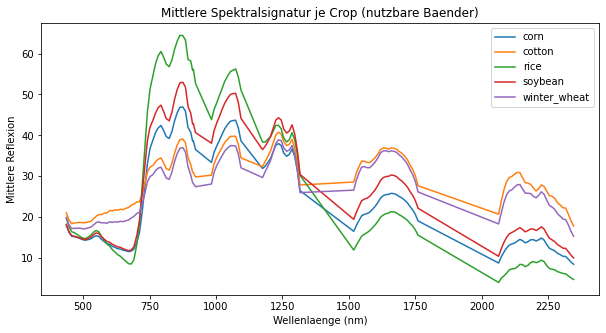

In [4]:
usable_cols = [c for c in spec_cols if c not in full_na.index]
wavelengths = [int(c[1:]) for c in usable_cols]
order = np.argsort(wavelengths)
wavelengths_sorted = np.array(wavelengths)[order]
usable_sorted = np.array(usable_cols)[order]

plt.figure(figsize=(10, 5))
for crop, group in df.groupby('Crop'):
    mean_signature = group[usable_sorted].mean()
    plt.plot(wavelengths_sorted, mean_signature.values, label=crop)
plt.xlabel('Wellenlaenge (nm)')
plt.ylabel('Mittlere Reflexion')
plt.title('Mittlere Spektralsignatur je Crop (nutzbare Baender)')
plt.legend()
plt.show()

## Zusammenfassung
- 67 von 198 Spektralband-Spalten sind vollstaendig leer (bekannte Absorptionsbereiche) -> droppen.
- 6 Spalten haben vereinzelt fehlende Werte (<0,5%) -> Median-Imputation ausreichend.
- Crop- und Stage-Klassen sind deutlich unausgeglichen -> `class_weight="balanced"` im Baseline-Modell.
- Spektralsignaturen unterscheiden sich sichtbar zwischen den Crops -> Klassifikation auf Basis der Baender ist plausibel.